## **Predicting Electric Vehicle Purchases**
https://www.kaggle.com/competitions/playground-series-s6e9/data

| 변수명 | 한국어 의미 |
|--------|-------------|
| `id` | 고유 식별 번호 |
| `Age` | 나이 |
| `Gender` | 성별 |
| `Annual_Income_USD` | 연간 소득(USD) |
| `City_Type` | 거주 지역 유형 |
| `Daily_Commute_km` | 하루 평균 통근 거리(km) |
| `Current_Car_Type` | 현재 보유 차량 종류 |
| `Number_of_Cars_Owned` | 보유 차량 대수 |
| `Home_Charging_Possible` | 가정에서 충전 가능 여부 |
| `Charging_Stations_Near_Home` | 집 주변 충전소 수 |
| `Charging_Stations_Near_Work` | 직장 주변 충전소 수 |
| `Environmental_Concern_Level` | 환경에 대한 관심 수준 |
| `Subsidy_Available` | 전기차 구매 보조금 지원 여부 |
| `Range_Anxiety_Level` | 주행거리 불안 수준 |
| `Will_Buy_EV` | 전기차 구매 여부 |

In [85]:
from sklearn import set_config
set_config(display="text")
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split           #---- 문제답 분리

from sklearn.linear_model import LogisticRegression             #---- 분류모델(선형모델)
from sklearn.ensemble import RandomForestClassifier,  HistGradientBoostingClassifier             #---- 분류모델(트리모델)   
from sklearn.ensemble import VotingClassifier, VotingRegressor  #---- 분류모델(앙상블)  
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve #---- 평가 메트릭스
from sklearn.metrics import roc_auc_score, roc_curve     #---- 평가 메트릭스

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate  #----교차검증

from sklearn.preprocessing import LabelEncoder, OneHotEncoder                       #-----인코딩(글자->숫자변경)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler        #-----정규화(스케일링)
from sklearn.decomposition import PCA                                               #-----차원축소
from sklearn.feature_selection import SelectFromModel 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# **[1] Data Load**

In [86]:
train = pd.read_csv("../datas/s6e9/train.csv")   
test  = pd.read_csv("../datas/s6e9/test.csv") 
sub   = pd.read_csv("../datas/s6e9/sample_submission.csv")

In [87]:
traincp = train.copy()
traincp.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [88]:
train.shape, test.shape, sub.shape

((668665, 15), (286571, 14), (286571, 2))

* 소문자로 변경 

In [89]:
train.columns = train.columns.str.lower()
test.columns  = test.columns.str.lower()
sub.columns  = sub.columns.str.lower()

In [90]:
train = train.rename(columns={
    'annual_income_usd': 'income',
    'city_type': 'city',
    'daily_commute_km': 'commute',
    'current_car_type': 'car',
    'number_of_cars_owned': 'cars',
    'home_charging_possible': 'home_charge',
    'charging_stations_near_home': 'home_station',
    'charging_stations_near_work': 'work_station',
    'environmental_concern_level': 'environment',
    'subsidy_available': 'subsidy',
    'range_anxiety_level': 'range_anxiety',
    'will_buy_ev': 'target'
})
test = test.rename(columns={
    'annual_income_usd': 'income',
    'city_type': 'city',
    'daily_commute_km': 'commute',
    'current_car_type': 'car',
    'number_of_cars_owned': 'cars',
    'home_charging_possible': 'home_charge',
    'charging_stations_near_home': 'home_station',
    'charging_stations_near_work': 'work_station',
    'environmental_concern_level': 'environment',
    'subsidy_available': 'subsidy',
    'range_anxiety_level': 'range_anxiety',
    'will_buy_ev': 'target'
})
sub = sub.rename(columns= {'will_buy_ev': 'target'})

In [91]:
train['gender'].value_counts()

gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64

In [92]:
train['car'].value_counts()

car
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

In [93]:
train['home_charge'].value_counts()

home_charge
Yes    462677
No     205988
Name: count, dtype: int64

In [94]:
train['range_anxiety'].value_counts()

range_anxiety
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64

* 인코딩

In [95]:
train['gender'] = train['gender'].map({"Male":0, "Female":1, "Other":2})
test['gender']  = test['gender'].map({"Male":0, "Female":1, "Other":2 })
train['city'] = train['city'].map({
    'Urban': 0,
    'Suburban': 1,
    'Rural': 2
})

train['car'] = train['car'].map({
    'Sedan': 0,
    'SUV': 1,
    'Hatchback': 2,
    'Truck': 3
})

train['home_charge'] = train['home_charge'].map({
    'No': 0,
    'Yes': 1
})

train['subsidy'] = train['subsidy'].map({
    'No': 0,
    'Yes': 1
})

train['range_anxiety'] = train['range_anxiety'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

test['city'] = test['city'].map({
    'Urban': 0,
    'Suburban': 1,
    'Rural': 2
})

test['car'] = test['car'].map({
    'Sedan': 0,
    'SUV': 1,
    'Hatchback': 2,
    'Truck': 3
})

test['home_charge'] = test['home_charge'].map({
    'No': 0,
    'Yes': 1
})

test['subsidy'] = test['subsidy'].map({
    'No': 0,
    'Yes': 1
})



test['range_anxiety'] =test['range_anxiety'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

train['target'] = train['target'].map({
    'No': 0,
    'Yes': 1
})


In [96]:
train.head()

,id,age,income,commute,cars,home_station,work_station,environment,gender,city,car,home_charge,subsidy,range_anxiety,target
0,0,66,92887.0,23.4,2,3,7,1.0,0,1,0,1,0,0,0
1,1,38,30000.0,5.0,1,2,2,4.0,0,2,1,1,0,0,0
2,2,26,94389.0,36.8,1,8,15,5.0,1,0,0,0,1,0,1
3,3,66,73580.0,23.7,2,6,9,3.0,0,1,2,1,0,0,0
4,4,54,57898.0,50.8,1,2,3,3.0,0,1,2,1,0,0,0


In [97]:
test.head()

,id,age,income,commute,cars,home_station,work_station,environment,gender,city,car,home_charge,subsidy,range_anxiety
0,668665,61,67725.0,16.9,2,7,4,4.0,0,1,0,1,0,0
1,668666,42,152835.0,41.9,2,9,9,4.0,0,0,1,0,0,0
2,668667,68,86877.0,53.3,1,10,11,4.0,1,0,0,0,0,0
3,668668,39,46794.0,34.1,2,4,8,4.0,1,1,0,1,0,0
4,668669,55,112172.0,57.2,1,6,4,1.0,1,1,0,1,1,0


In [98]:
sub.head()

,id,target
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645


In [ ]:
#train = train.drop(columns='id')
#test = test.drop(columns='id')
#sub = sub.drop(columns='id')

In [99]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             668665 non-null  int64  
 1   age            668665 non-null  int64  
 2   income         668665 non-null  float64
 3   commute        668665 non-null  float64
 4   cars           668665 non-null  int64  
 5   home_station   668665 non-null  int64  
 6   work_station   668665 non-null  int64  
 7   environment    668665 non-null  float64
 8   gender         668665 non-null  int64  
 9   city           668665 non-null  int64  
 10  car            668665 non-null  int64  
 11  home_charge    668665 non-null  int64  
 12  subsidy        668665 non-null  int64  
 13  range_anxiety  668665 non-null  int64  
 14  target         668665 non-null  int64  
dtypes: float64(3), int64(12)
memory usage: 76.5 MB


In [100]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 286571 entries, 0 to 286570
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             286571 non-null  int64  
 1   age            286571 non-null  int64  
 2   income         286571 non-null  float64
 3   commute        286571 non-null  float64
 4   cars           286571 non-null  int64  
 5   home_station   286571 non-null  int64  
 6   work_station   286571 non-null  int64  
 7   environment    286571 non-null  float64
 8   gender         286571 non-null  int64  
 9   city           286571 non-null  int64  
 10  car            286571 non-null  int64  
 11  home_charge    286571 non-null  int64  
 12  subsidy        286571 non-null  int64  
 13  range_anxiety  286571 non-null  int64  
dtypes: float64(3), int64(11)
memory usage: 30.6 MB


# **[2] 공통함수**

In [101]:
def myscore222(train, model=None, MY_TARGET="target"):
    
    X = train.drop(columns=[MY_TARGET])
    y = train[MY_TARGET]

    X_train7, X_test3, y_train7, y_test3 = train_test_split(
        X, y,
        test_size=0.2,
        random_state=1234,
        shuffle=True,
        stratify=y
    )

    scaler = StandardScaler()

    X_train7 = scaler.fit_transform(X_train7)
    X_test3 = scaler.transform(X_test3)

    if model is None:
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )

    print("Model:", model.__class__.__name__)

    model.fit(X_train7, y_train7)

    pred = model.predict(X_test3)
    pred_proba = model.predict_proba(X_test3)[:, 1]

    acc = accuracy_score(y_test3, pred)
    f1 = f1_score(y_test3, pred)
    precision = precision_score(y_test3, pred)
    recall = recall_score(y_test3, pred)
    auc = roc_auc_score(y_test3, pred_proba)

    print(
        f"acc : {acc:.4f}  "
        f"f1 : {f1:.4f}  "
        f"precision : {precision:.4f}  "
        f"recall : {recall:.4f}  "
        f"auc : {auc:.4f}"
    )

    cm = confusion_matrix(y_test3, pred)
    print(cm)

    return model, scaler

# **[3]EDA  Target 중심 분석 + Feature Engineering**
목표: `target`과 변수의 관계를 확인하고, AUC 개선을 위한 파생변수를 생성합니다.
`id`는 삭제하지 않습니다.


target
0    551886
1    116779
Name: count, dtype: int64
target
0    0.825355
1    0.174645
Name: proportion, dtype: float64


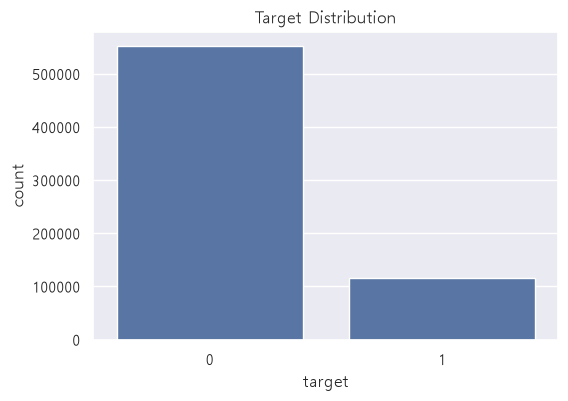

In [102]:
# Target 분포
print(train['target'].value_counts())
print(train['target'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(data=train, x='target')
plt.title('Target Distribution')
plt.show()


In [103]:
# 수치형 변수
num_cols = [
    'age', 'income', 'commute', 'cars',
    'home_station', 'work_station', 'environment'
]

train.groupby('target')[num_cols].agg(['mean', 'median', 'std']).T


target                          0             1
age          mean       47.083293     46.830654
             median     47.000000     47.000000
             std        12.896488     12.773543
income       mean    81794.588556  98827.302948
             median  82844.000000  96167.000000
             std     28237.155138  26300.675910
commute      mean       32.553478     30.290714
             median     34.000000     31.700000
             std        18.820772     18.181942
cars         mean        1.711319      1.718802
             median      2.000000      2.000000
             std         0.730520      0.723336
home_station mean        4.989947      4.820807
             median      4.000000      4.000000
             std         3.919259      3.959525
work_station mean        7.205490      7.038432
             median      6.000000      6.000000
             std         5.185977      5.187498
environment  mean        2.630395      4.377268
             median      2.000000      5.000000
             std         1.338342      0.843211

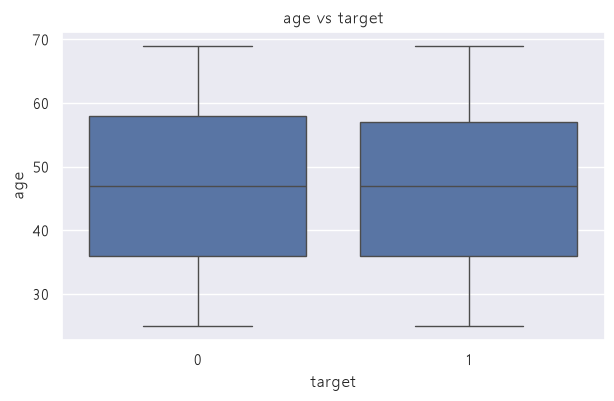

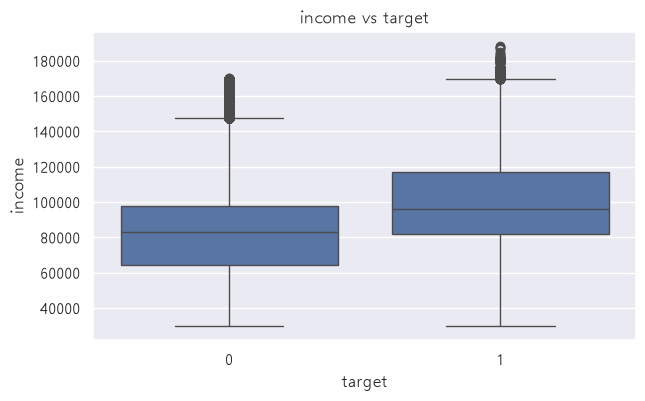

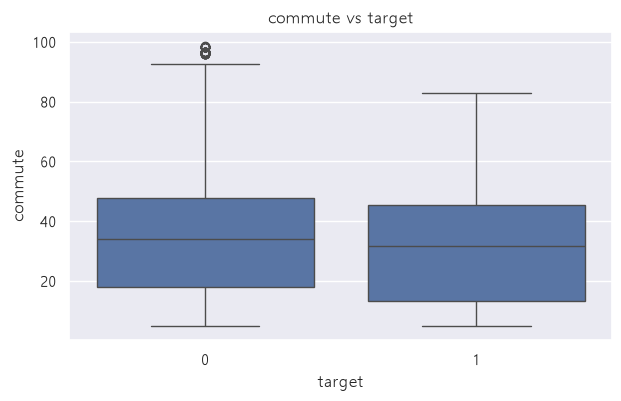

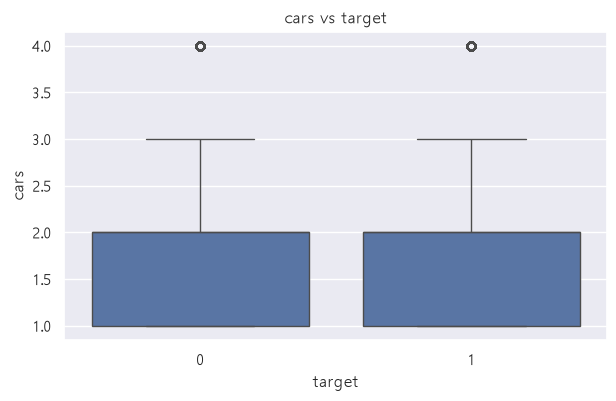

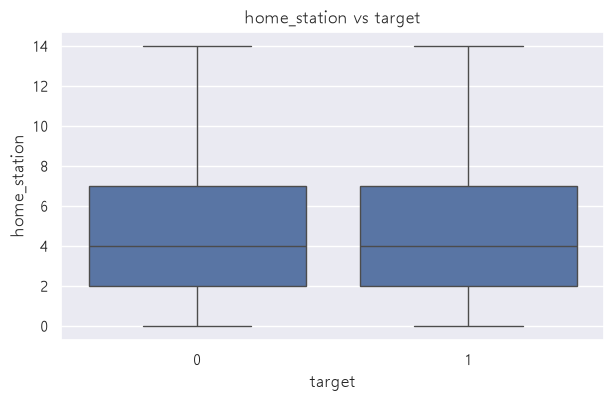

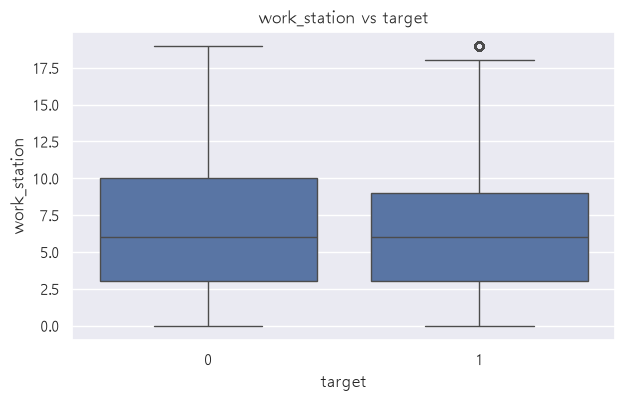

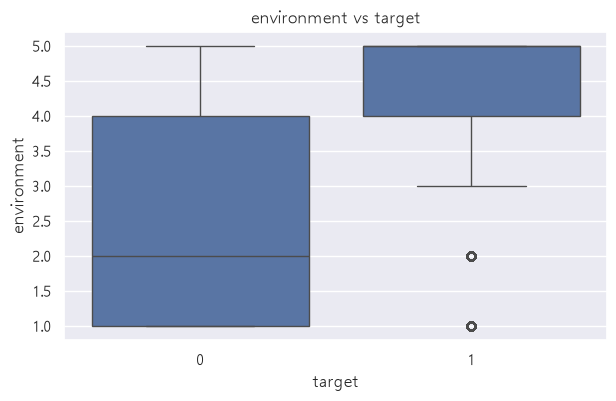

In [104]:
# Target별 수치형 변수 분포
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=train, x='target', y=col)
    plt.title(f'{col} vs target')
    plt.show()


In [105]:
# 범주형 변수별 Target 비율
cat_cols = [
    'gender', 'city', 'home_charge',
    'subsidy', 'range_anxiety'
]

for col in cat_cols:
    print(f'\n===== {col} =====')
    print(
        train.groupby(col)['target']
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
    )



===== gender =====
            mean   count
gender                  
1       0.177641  295427
2       0.173732    5284
0       0.172253  367954

===== city =====
          mean   count
city                  
2     0.193389  123983
1     0.180936  255377
0     0.161058  289305

===== home_charge =====
                 mean   count
home_charge                  
1            0.195819  462677
0            0.127085  205988

===== subsidy =====
             mean   count
subsidy                  
1        0.274695  419909
0        0.005757  248756

===== range_anxiety =====
                   mean   count
range_anxiety                  
0              0.189027  603972
1              0.041745   62499
2              0.001367    2194


In [ ]:
# 범주형 변수별 구매율 시각화
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.barplot(data=train, x=col, y='target')
    plt.title(f'Target Rate by {col}')
    plt.ylabel('EV Purchase Rate')
    plt.show()


                     mean  count
income_group_10                 
0                0.044486  66942
1                0.084593  66861
2                0.106622  66834
3                0.131650  66844
4                0.156083  66977
5                0.179741  67013
6                0.197670  66616
7                0.219553  66854
8                0.289040  66970
9                0.337313  66754


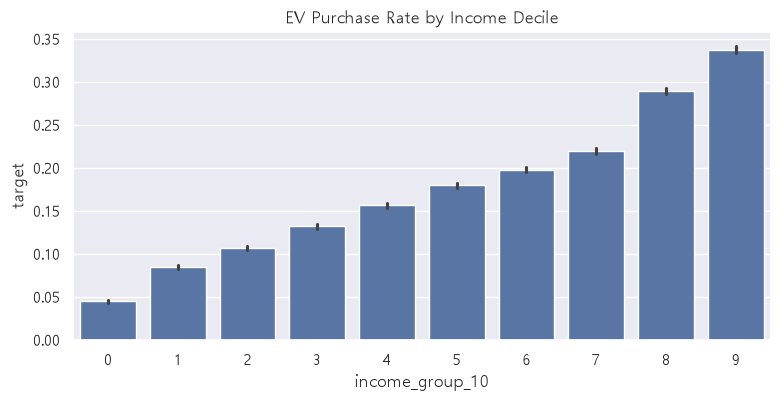

In [107]:
# Income 구간별 구매율
train['income_group_10'] = pd.qcut(
    train['income'],
    q=10,
    labels=False,
    duplicates='drop'
)

print(
    train.groupby('income_group_10')['target']
    .agg(['mean', 'count'])
)

plt.figure(figsize=(9,4))
sns.barplot(data=train, x='income_group_10', y='target')
plt.title('EV Purchase Rate by Income Decile')
plt.show()


In [ ]:
# Commute 구간별 구매율
train['commute_group'] = pd.cut(
    train['commute'],
    bins=[-1, 10, 30, 50, 100, np.inf],
    labels=False
)

print(
    train.groupby('commute_group')['target']
    .agg(['mean', 'count'])
)

plt.figure(figsize=(8,4))
sns.barplot(data=train, x='commute_group', y='target')
plt.title('EV Purchase Rate by Commute Group')
plt.show()


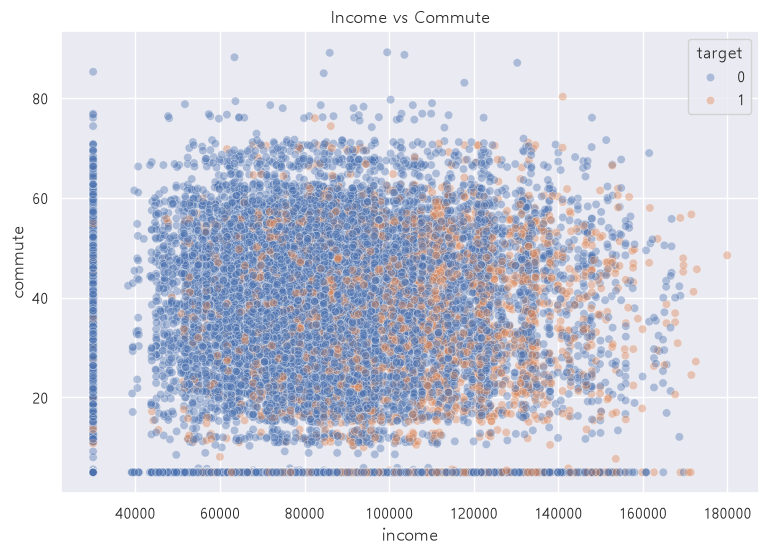

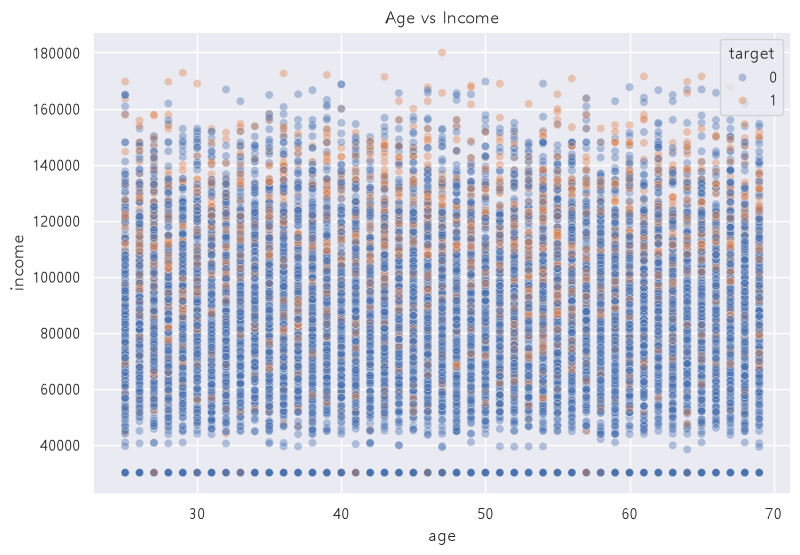

In [108]:
# 주요 변수 Interaction EDA
sample_eda = train.sample(min(20000, len(train)), random_state=1234)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=sample_eda,
    x='income',
    y='commute',
    hue='target',
    alpha=0.4
)
plt.title('Income vs Commute')
plt.show()

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=sample_eda,
    x='age',
    y='income',
    hue='target',
    alpha=0.4
)
plt.title('Age vs Income')
plt.show()


## [Feature Engineering] EDA에서 확인한 관계를 파생변수로 반영


In [109]:
# train/test에 동일한 파생변수 생성
for df in [train, test]:

    # 충전 인프라
    df['total_station'] = df['home_station'] + df['work_station']

    # 충전 접근성
    df['charge_score'] = df['home_charge'] + df['total_station']

    # 출퇴근 × 충전 인프라
    df['commute_station'] = df['commute'] * (1 + df['total_station'])

    # 소득 대비 출퇴근
    df['income_commute'] = df['income'] / (df['commute'] + 1)

    # 소득 대비 차량 보유
    df['income_per_car'] = df['income'] / (df['cars'] + 1)

    # 나이 × 소득
    df['age_income'] = df['age'] * df['income']

    # 출퇴근 × 차량
    df['commute_cars'] = df['commute'] * (df['cars'] + 1)

    # 집/직장 충전소 차이
    df['station_diff'] = df['home_station'] - df['work_station']

    # 집 충전소 비율
    df['home_station_ratio'] = (
        df['home_station'] / (df['total_station'] + 1)
    )

    # 차량 대비 충전 인프라
    df['station_per_car'] = (
        df['total_station'] / (df['cars'] + 1)
    )

    # 환경 × 출퇴근
    df['environment_commute'] = (
        df['environment'] * df['commute']
    )

    # 환경 × 소득
    df['environment_income'] = (
        df['environment'] * df['income']
    )

    # 충전 여부 × 보조금
    df['charge_subsidy'] = (
        df['home_charge'] * df['subsidy']
    )

    # 보조금 × 소득
    df['subsidy_income'] = (
        df['subsidy'] * df['income']
    )


In [110]:
# 새 Feature가 Target과 관계가 있는지 확인
new_cols = [
    'total_station',
    'charge_score',
    'commute_station',
    'income_commute',
    'income_per_car',
    'age_income',
    'commute_cars',
    'station_diff',
    'home_station_ratio',
    'station_per_car',
    'environment_commute',
    'environment_income',
    'charge_subsidy',
    'subsidy_income'
]

train.groupby('target')[new_cols].mean().T


target,0,1
total_station,1.219544e+01,1.185924e+01
charge_score,1.286963e+01,1.263507e+01
commute_station,4.360856e+02,3.965157e+02
income_commute,4.691682e+03,6.034045e+03
income_per_car,3.223837e+04,3.880590e+04
age_income,3.849520e+06,4.629814e+06
commute_cars,8.830210e+01,8.239590e+01
station_diff,-2.215543e+00,-2.217625e+00
home_station_ratio,3.521829e-01,3.458219e-01
station_per_car,4.798421e+00,4.647592e+00


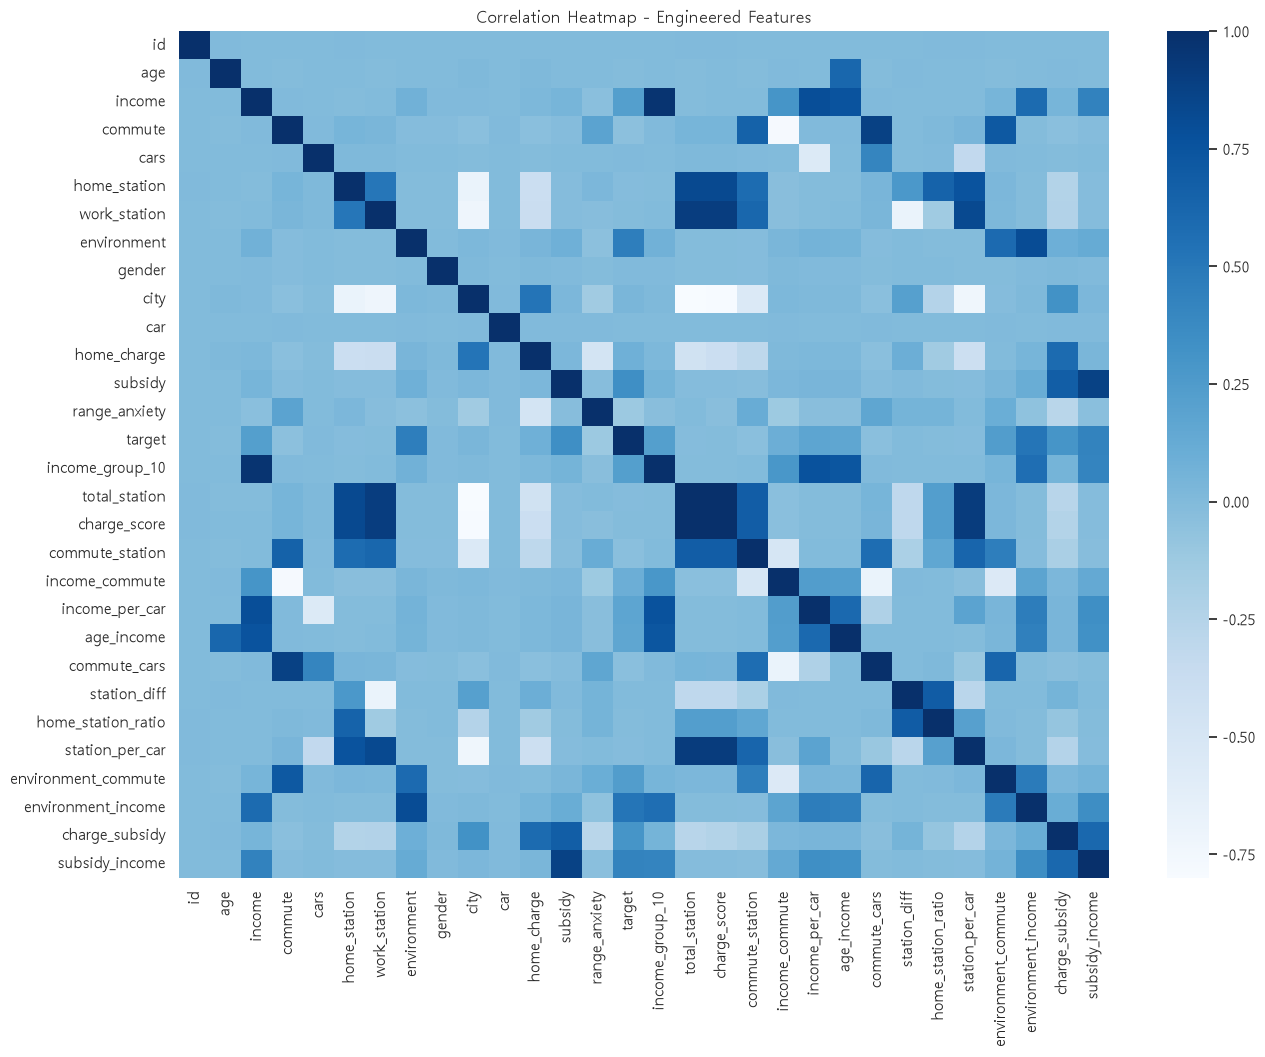

In [111]:
# 새 변수 포함 상관관계
plt.figure(figsize=(15,11))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='Blues')
plt.title('Correlation Heatmap - Engineered Features')
plt.show()


## [AUC 모델] Scaling 없이 LightGBM 평가
트리 기반 모델인 LightGBM에서는 StandardScaler를 사용하지 않고 평가합니다.


In [112]:
def myscore_lgbm(train, model, MY_TARGET='target'):

    X = train.drop(columns=[MY_TARGET])
    y = train[MY_TARGET]

    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y,
        test_size=0.2,
        random_state=1234,
        stratify=y
    )

    model.fit(X_train, y_train)

    pred_proba = model.predict_proba(X_valid)[:, 1]
    pred = (pred_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_valid, pred_proba)

    print('Model:', model.__class__.__name__)
    print(f'AUC : {auc:.4f}')
    print(f'ACC : {accuracy_score(y_valid, pred):.4f}')
    print(f'F1  : {f1_score(y_valid, pred):.4f}')

    return model


In [118]:
myscore222(train,model = LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.2,
    reg_lambda=2.0,
    random_state=1234,
    n_jobs=-1,
    verbosity=-1
))

Model: LGBMClassifier
acc : 0.8976  f1 : 0.6966  precision : 0.7220  recall : 0.6730  auc : 0.9413
[[104324   6053]
 [  7638  15718]]


(LGBMClassifier(colsample_bytree=0.85, learning_rate=0.02, min_child_samples=50,
                n_estimators=1500, n_jobs=-1, random_state=1234, reg_alpha=0.2,
                reg_lambda=2.0, subsample=0.85, verbosity=-1),
 StandardScaler())

## hist() : 데이터 분포도(왜도,첨도,정규분포)

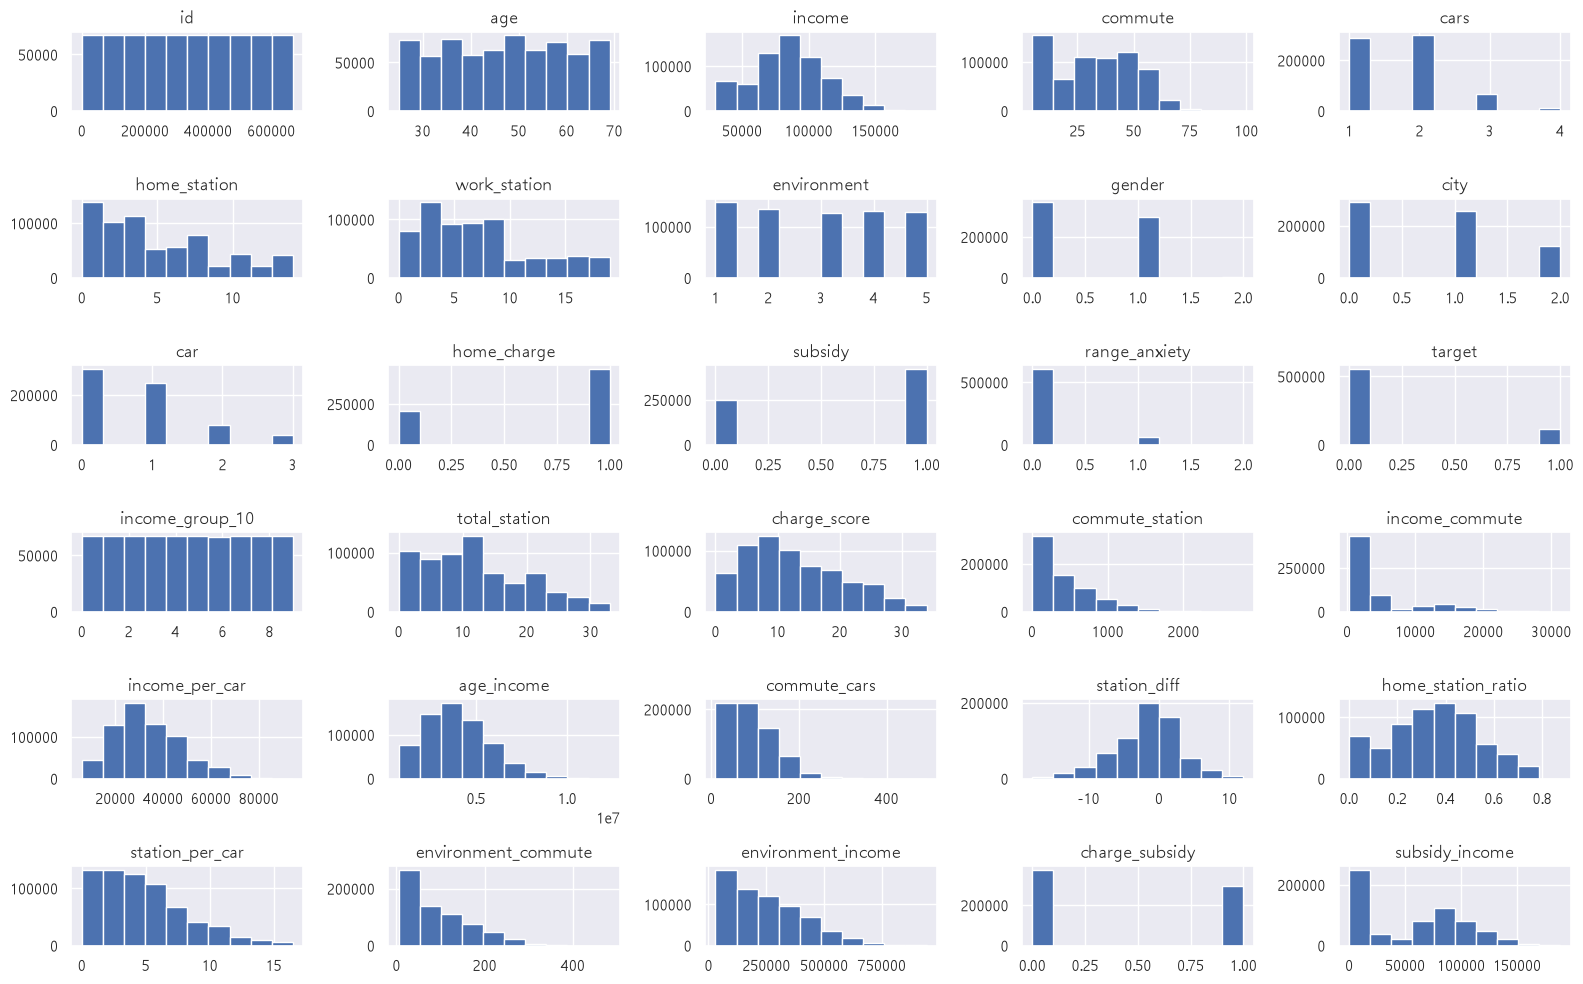

In [119]:
train.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

## 결측여부

In [120]:
train.isna().sum()

id                     0
age                    0
income                 0
commute                0
cars                   0
home_station           0
work_station           0
environment            0
gender                 0
city                   0
car                    0
home_charge            0
subsidy                0
range_anxiety          0
target                 0
income_group_10        0
total_station          0
charge_score           0
commute_station        0
income_commute         0
income_per_car         0
age_income             0
commute_cars           0
station_diff           0
home_station_ratio     0
station_per_car        0
environment_commute    0
environment_income     0
charge_subsidy         0
subsidy_income         0
dtype: int64

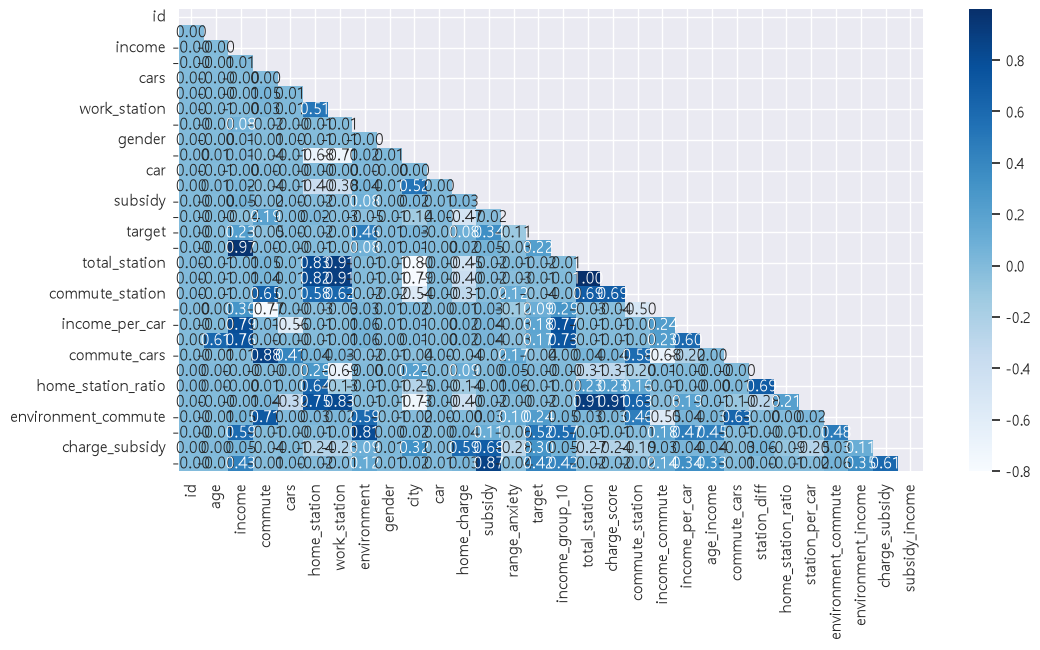

In [121]:
plt.figure(figsize=(12, 6))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.show()

In [122]:
traincp = train.copy()

In [123]:
traincp

,id,age,income,commute,cars,home_station,work_station,environment,gender,city,...,income_per_car,age_income,commute_cars,station_diff,home_station_ratio,station_per_car,environment_commute,environment_income,charge_subsidy,subsidy_income
0,0,66,92887.0,23.4,2,3,7,1.0,0,1,...,30962.333333,6130542.0,70.2,-4,0.272727,3.333333,23.4,92887.0,0,0.0
1,1,38,30000.0,5.0,1,2,2,4.0,0,2,...,15000.000000,1140000.0,10.0,0,0.400000,2.000000,20.0,120000.0,0,0.0
2,2,26,94389.0,36.8,1,8,15,5.0,1,0,...,47194.500000,2454114.0,73.6,-7,0.333333,11.500000,184.0,471945.0,0,94389.0
3,3,66,73580.0,23.7,2,6,9,3.0,0,1,...,24526.666667,4856280.0,71.1,-3,0.375000,5.000000,71.1,220740.0,0,0.0
4,4,54,57898.0,50.8,1,2,3,3.0,0,1,...,28949.000000,3126492.0,101.6,-1,0.333333,2.500000,152.4,173694.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,0,0,...,23696.666667,2132700.0,82.2,-1,0.416667,3.666667,137.0,355450.0,0,71090.0
668661,668661,32,129990.0,5.0,2,5,4,1.0,1,1,...,43330.000000,4159680.0,15.0,1,0.500000,3.000000,5.0,129990.0,1,129990.0
668662,668662,64,121791.0,24.2,1,5,6,1.0,1,1,...,60895.500000,7794624.0,48.4,-1,0.416667,5.500000,24.2,121791.0,1,121791.0
668663,668663,51,115923.0,43.7,2,0,0,1.0,1,2,...,38641.000000,5912073.0,131.1,0,0.000000,0.000000,43.7,115923.0,1,115923.0


In [124]:
for df in [train, test]:

    # 충전소 총 개수
    df['total_station'] = (
        df['home_station'] + df['work_station']
    )

    # 집에서 충전 가능 + 충전소
    df['charge_score'] = (
        df['home_charge'].map({'Yes': 1, 'No': 0})
        + df['total_station']
    )

    # 소득 구간
    df['income_group'] = pd.qcut(
        df['income'],
        q=5,
        labels=False,
        duplicates='drop'
    )

    # 출퇴근 거리 구간
    df['commute_group'] = pd.cut(
        df['commute'],
        bins=[-1, 10, 30, 50, 100, float('inf')],
        labels=False
    )

    # 차량 보유 수 구간
    df['cars_group'] = pd.cut(
        df['cars'],
        bins=[-1, 0, 1, 2, float('inf')],
        labels=False
    )

# **[4]점수**

## **1차 점수:0.9348 (RandomForestClassifier)**

In [ ]:
myscore222(train)

Model: RandomForestClassifier


## **2차 점수:0.9377  (LogisticRegression)**

In [126]:
 myscore222(train,model=LogisticRegression())

Model: LogisticRegression


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## **3차 점수: 0.9402 (XGBClassifier)**

In [ ]:
myscore222(train,model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
))


## **4차 점수 :  0.9406(HistGradientBoostingClassifier)**

In [ ]:
myscore222(train, model =(HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=1234
    )))

## **5차 점수 : 0.9413( VotingClassifier)**

In [ ]:
lgb = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=1234,
    n_jobs=-1,
    verbosity=-1
)

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric="logloss",
    random_state=1234,
    n_jobs=-1
)

model = VotingClassifier(
    estimators=[
        ("lgb", lgb),
        ("xgb", xgb)
    ],
    voting="soft",
    weights=[1, 1]
)

model, scaler = myscore222(
    train,
    model=model,
    MY_TARGET="target"
)
X_test = scaler.transform(test)
pred_proba = model.predict_proba(X_test)[:, 1]
sub = pd.DataFrame({
    'id': test['id'],
    'target': pred_proba
})
sub.to_csv('elec1.csv', index=False)
print(sub.head())

## **6차 점수 :0.9410(LGBMClassifier)**

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=1234
)

myscore222(train, model=model, MY_TARGET="target")

In [ ]:
myscore222(train, model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
))